In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

sys.path.append(os.path.abspath(".."))

In [3]:
from datetime import datetime, timedelta

import polars as pl

from tests.helpers.collector import PolarsCollector
from tests.helpers.simulation_runner import SimulationTestRunner
from thrs.classes.machine_state_logger import MachineStateLoggingServiceNoop
from thrs.control.modules.adsorption import (
    AdsorptionAlarms,
    AdsorptionControl,
    AdsorptionParameters,
)
from thrs.input_output.base import Stamped
from thrs.input_output.definitions.simulation import (
    AdsorptionChiller,
    Boundary,
    TemperatureBoundary,
)
from thrs.input_output.modules.adsorption import (
    AdsorptionControlValues,
    AdsorptionSensorValues,
    AdsorptionSimulationInputs,
    AdsorptionSimulationOutputs,
)
from thrs.orchestration.simulation import Simulation
from thrs.simulation.fmu import Fmu
from thrs.simulation.models.fmu_paths import adsorption_path

start_time = datetime.fromtimestamp(0)
minutes = 10
duration = timedelta(minutes=minutes - 1)
time_index = pl.datetime_range(
    start_time,
    start_time + duration,
    interval="1m",
    time_unit="us",
    eager=True,
)


simulation_inputs = AdsorptionSimulationInputs(
    adsorption_cooling_supply=TemperatureBoundary(temperature=Stamped.stamp(20.0)),
    adsorption_seawater_supply=Boundary(
        temperature=Stamped.stamp(20.0), flow=Stamped.stamp(64.0)
    ),
    adsorption_available_cold_temperature=TemperatureBoundary(
        temperature=Stamped.stamp(20.0)
    ),
    adsorption_available_hot_temperature=TemperatureBoundary(
        temperature=Stamped.stamp(65.0)
    ),
    adsorption_available_seawater_temperature=TemperatureBoundary(
        temperature=Stamped.stamp(30.0)
    ),
    adsorption_chiller=AdsorptionChiller(free_cooling=Stamped.stamp(False)),
    adsorption_consumers_supply=Boundary(
        temperature=Stamped.stamp(60.0), flow=Stamped.stamp(42.0)
    ),
    adsorption_dhw_supply=Boundary(
        temperature=Stamped.stamp(10.0), flow=Stamped.stamp(45.0)
    ),
)

parameters = AdsorptionParameters(
    chiller_enabled=True,
    waste_cooling_temperature_setpoint=35.0,
    waste_recovery_temperature_setpoint=40.0,
    hot_supply_temperature_setpoint=60.0,
    adsorption_cooling_setpoint=17.0,
    adsorption_hot_minimum=50.0,
    adsorption_hot_trigger=55.0,
    adsorption_cold_minimum=10.0,
    adsorption_cold_trigger=17.0,
    hot_mix_tuning=(0.05, 0.001, 0),
    recovery_tuning=(0.05, 0.001, 0),
    waste_cooling_tuning=(0.05, 0.01, 0),
    free_cooling_enabled=False,
)

with Fmu(adsorption_path) as fmu:
    simulation = Simulation(
        AdsorptionSensorValues,
        AdsorptionSimulationOutputs,
        fmu,
        simulation_inputs,
        start_time,
        timedelta(seconds=1),
    )
    control = AdsorptionControl(
        parameters, simulation.time, MachineStateLoggingServiceNoop()
    )
    runner = SimulationTestRunner(simulation, control, AdsorptionAlarms())
    collector = PolarsCollector()
    runner.run(int(duration.total_seconds()), collector)
    result = collector.result()

[WARNING] State logging: Please enable result storing to get state names


/Users/alje/Repos/zero/zero-thrs-control/analysis/analysis_utils.py:406: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(
/Users/alje/Repos/zero/zero-thrs-control/analysis/analysis_utils.py:406: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


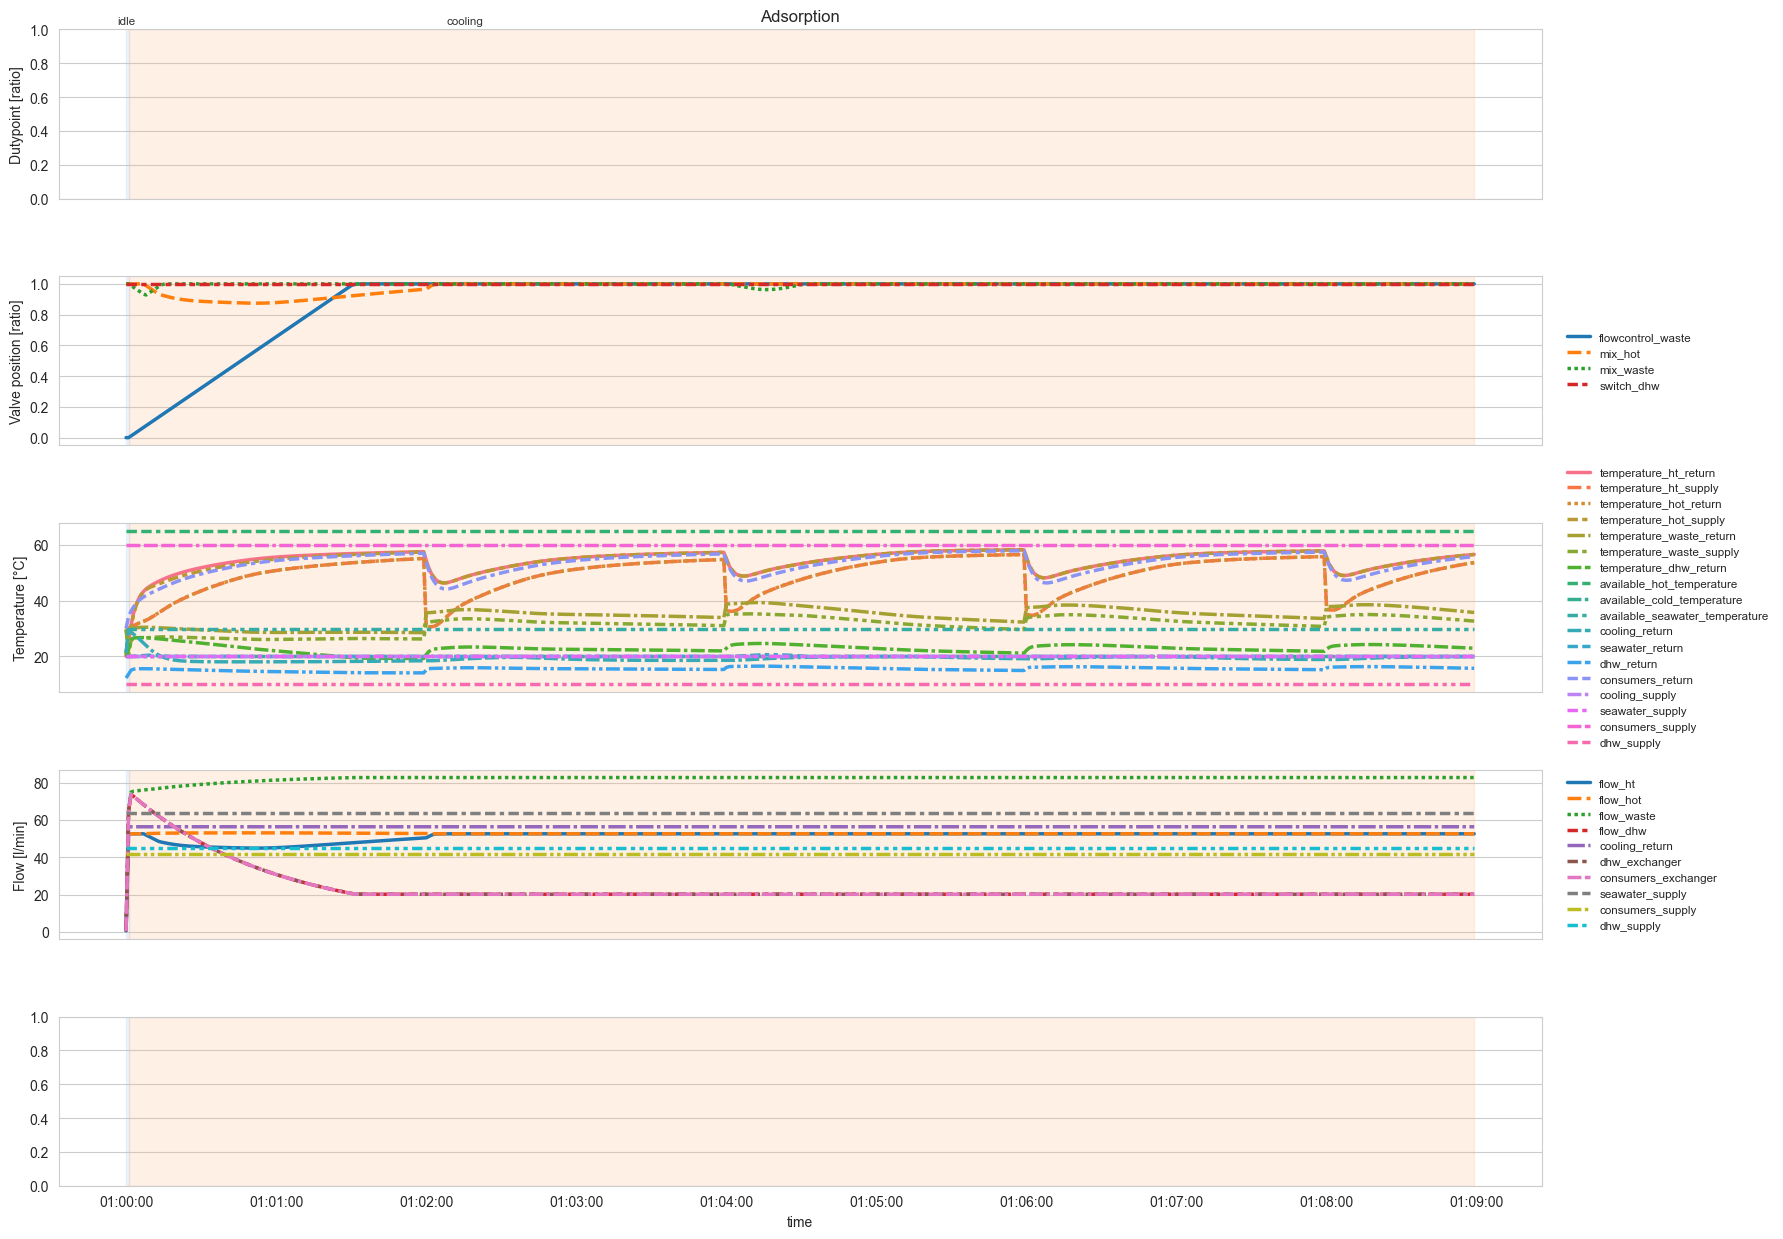

In [4]:
from analysis.analysis_utils import plot_result

plot_result(result, "plots/adsorption.png");

<Axes: >

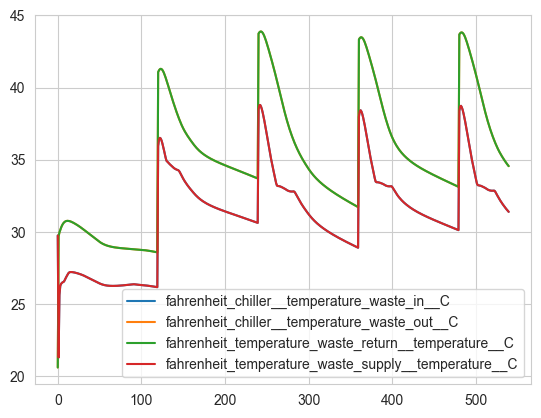

In [53]:
result[[col for col in result.columns if "temperature_waste" in col]].to_pandas().plot()

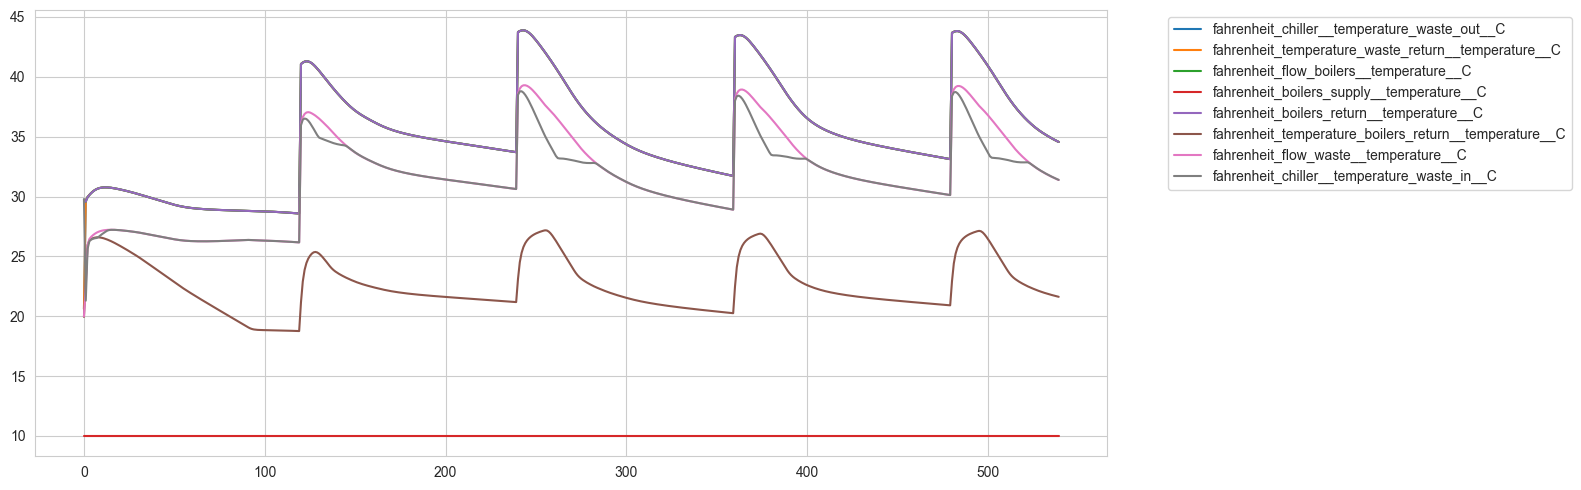

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 5))

result[
    [
        "adsorption_chiller__temperature_waste_out__C",
        "adsorption_temperature_waste_return__temperature__C",
        "adsorption_flow_boilers__temperature__C",
        "adsorption_boilers_supply__temperature__C",
        "adsorption_boilers_return__temperature__C",
        "adsorption_temperature_boilers_return__temperature__C",
        "adsorption_flow_waste__temperature__C",
        "adsorption_chiller__temperature_waste_in__C",
    ]
].to_pandas().plot(ax=ax)

ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

In [ ]:
from thrs.simulation.io_mapping import build_fmu_key_mapping

result.select(
    [
        "time",
        *build_fmu_key_mapping(AdsorptionControlValues, fmu_only=False).values(),
        *build_fmu_key_mapping(AdsorptionSimulationInputs, fmu_only=False).values(),
    ]
).write_csv("csv/pvt_run_inputs.csv")


result.select(
    [
        "time",
        *build_fmu_key_mapping(AdsorptionSensorValues, fmu_only=False).values(),
        *build_fmu_key_mapping(AdsorptionSimulationOutputs, fmu_only=False).values(),
    ]
).write_csv("csv/adsorption_run_outputs.csv")